In [2]:
import numpy as py
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
df=pd.read_csv("C:/Users/vasan/Downloads/load_forecasting_dataset_corrected.csv")

In [15]:
print(df.columns)

Index(['Timestamp', 'Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)',
       'Rainfall (mm)', 'Solar Irradiance (W/m²)', 'GDP (LKR)',
       'Per Capita Energy Use (kWh)', 'Electricity Price (LKR/kWh)',
       'Day of Week', 'Hour of Day', 'Month', 'Season', 'Public Event',
       'Load Demand (kW)'],
      dtype='str')


In [16]:
df.isnull().sum()

Timestamp                      0
Temperature (°C)               0
Humidity (%)                   0
Wind Speed (m/s)               0
Rainfall (mm)                  0
Solar Irradiance (W/m²)        0
GDP (LKR)                      0
Per Capita Energy Use (kWh)    0
Electricity Price (LKR/kWh)    0
Day of Week                    0
Hour of Day                    0
Month                          0
Season                         0
Public Event                   0
Load Demand (kW)               0
dtype: int64

In [17]:
print(df.duplicated)

<bound method DataFrame.duplicated of               Timestamp  Temperature (°C)  Humidity (%)  Wind Speed (m/s)  \
0         1/1/2020 0:00         28.993428     75.011269          1.053861   
1         1/1/2020 0:15         27.723471     77.024015          1.085152   
2         1/1/2020 0:30         29.295377     74.732958          3.363800   
3         1/1/2020 0:45         31.046060     87.615995          2.539148   
4         1/1/2020 1:00         27.531693     79.709858          1.366819   
...                 ...               ...           ...               ...   
189883  5/31/2025 22:45         27.433177     82.943227          1.564385   
189884  5/31/2025 23:00         32.085127     84.159944          1.389473   
189885  5/31/2025 23:15         27.620201     87.091108          2.722335   
189886  5/31/2025 23:30         29.378415     75.743129          2.317605   
189887  5/31/2025 23:45         27.737078     83.529497          0.914573   

        Rainfall (mm)  Solar Irradian

In [18]:
pd.to_datetime(df["Timestamp"])

0        2020-01-01 00:00:00
1        2020-01-01 00:15:00
2        2020-01-01 00:30:00
3        2020-01-01 00:45:00
4        2020-01-01 01:00:00
                 ...        
189883   2025-05-31 22:45:00
189884   2025-05-31 23:00:00
189885   2025-05-31 23:15:00
189886   2025-05-31 23:30:00
189887   2025-05-31 23:45:00
Name: Timestamp, Length: 189888, dtype: datetime64[us]

In [19]:
df["Date"]=pd.to_datetime(df["Timestamp"],errors="coerce")

In [20]:
df.head()

,Timestamp,Temperature (°C),Humidity (%),Wind Speed (m/s),Rainfall (mm),Solar Irradiance (W/m²),GDP (LKR),Per Capita Energy Use (kWh),Electricity Price (LKR/kWh),Day of Week,Hour of Day,Month,Season,Public Event,Load Demand (kW),Date
0,1/1/2020 0:00,28.993428,75.011269,1.053861,4.140513,185.892561,925.621430,502.915605,20.454440,2,0,1,Summer,0,1599.342831,2020-01-01 00:00:00
1,1/1/2020 0:15,27.723471,77.024015,1.085152,9.446997,281.782650,1020.823521,497.286366,27.776449,2,0,1,Summer,0,1472.347140,2020-01-01 00:15:00
2,1/1/2020 0:30,29.295377,74.732958,3.363800,4.265813,328.942058,1028.847455,488.816292,21.097420,2,0,1,Summer,0,1629.537708,2020-01-01 00:30:00
3,1/1/2020 0:45,31.046060,87.615995,2.539148,1.038103,336.407064,937.963002,468.038834,26.032137,2,0,1,Summer,1,1804.605971,2020-01-01 00:45:00
4,1/1/2020 1:00,27.531693,79.709858,1.366819,4.201393,205.494256,934.477462,488.565716,27.079114,2,1,1,Summer,0,1453.169325,2020-01-01 01:00:00


Text(0.5, 1.0, 'Temperature VS Humidity')

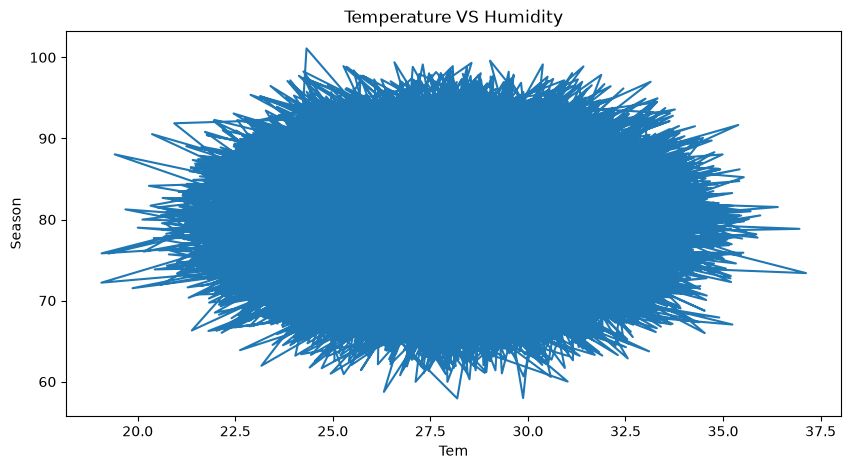

In [21]:
plt.figure(figsize=(10,5))
plt.plot(df['Temperature (°C)'],df['Humidity (%)'])

plt.xlabel("Tem")
plt.ylabel("Season")
plt.title("Temperature VS Humidity")

In [22]:
df["Average"]=df["Wind Speed (m/s)"].rolling(window=5).mean()
df.tail()

,Timestamp,Temperature (°C),Humidity (%),Wind Speed (m/s),Rainfall (mm),Solar Irradiance (W/m²),GDP (LKR),Per Capita Energy Use (kWh),Electricity Price (LKR/kWh),Day of Week,Hour of Day,Month,Season,Public Event,Load Demand (kW),Date,Average
189883,5/31/2025 22:45,27.433177,82.943227,1.564385,0.476854,214.276578,986.122824,487.823955,17.183842,5,22,5,Fall,0,1443.317681,2025-05-31 22:45:00,1.925198
189884,5/31/2025 23:00,32.085127,84.159944,1.389473,0.309841,308.798749,970.258350,515.405431,29.773656,5,23,5,Fall,0,1908.512650,2025-05-31 23:00:00,1.663357
189885,5/31/2025 23:15,27.620201,87.091108,2.722335,1.422315,282.487744,1007.429961,509.295868,24.883951,5,23,5,Fall,0,1462.020111,2025-05-31 23:15:00,2.164144
189886,5/31/2025 23:30,29.378415,75.743129,2.317605,9.383305,246.291089,1019.239724,536.514530,27.765615,5,23,5,Fall,0,1637.841485,2025-05-31 23:30:00,1.966928
189887,5/31/2025 23:45,27.737078,83.529497,0.914573,9.901955,299.088224,1020.425273,518.742211,15.496762,5,23,5,Fall,0,1473.707828,2025-05-31 23:45:00,1.781674


In [23]:
for i in range (1,11):
    value1=df["Wind Speed (m/s)"].iloc[i]
    value2=df["Wind Speed (m/s)"].iloc[-i]
    if value2 > value1:
        print("Increasing Trend")
    elif value2 < value1:
        print("Decreasing Trend")
    else:
        print("Stable Trend")

Decreasing Trend
Decreasing Trend
Increasing Trend
Increasing Trend
Decreasing Trend
Increasing Trend
Increasing Trend
Decreasing Trend
Increasing Trend
Decreasing Trend
